# Create Infrastructure Barcharts

This notebook provides the code to create barcharts of (1) new and retired power plant capacity through 2050 by state and technology and (2) land usage and land availability (km-squared) through 2050 by state and technology

### Imports

In [2]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from PIL import Image
import os

### Settings

In [3]:
color_map_dict={
    'Natural Gas':'#bdb59d',
    'Coal': '#75736d',
    'Solar PV': '#F7B615',
    'Solar CSP': '#f1781b',
    'Wind': '#95C060', 
    'Nuclear': '#6D547C', 
    'Offshore Wind':'#2B7F9E', 
    'Biomass': '#713275',
    'Geothermal': '#BB3B1C', 
    'Oil': '#BB3B1C',
    'Hydro': '#14345e'}

### Data Paths

In [4]:
# data dir
data_dir = os.path.join(os.path.dirname(os.getcwd()), 'data', 'input_data')

# output figure dir
fig_dir = os.path.join(os.path.dirname(os.getcwd()), 'figures')

# infrastructure siting output csv
infrastucture_path = os.path.join(data_dir, 'infrastructure_data_csv', 'infrastructure_data.csv')

# infrastructure retirement csv
retirement_path = os.path.join(data_dir, 'infrastructure_data_csv', 'retirement_data.csv')

# CONUS shapefile
conus_shp_path = os.path.join(data_dir, 'conus_shp', 'cb_2018_us_state_5m', 'cb_2018_us_state_5m.shp')

### Collect Data

In [6]:
# read in infrastructure data
df = pd.read_csv(infrastucture_path)

year = 2050

# reduce to year of interest
df = df[df.sited_year <=year]

# collect prepared retirement data
df_retired = pd.read_csv(retirement_path)

## Create Figures

#### Reference map

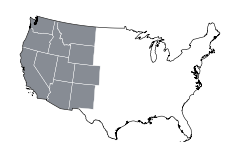

In [7]:
conus = gpd.read_file(conus_shp_path).to_crs('ESRI:102003')
conus = conus[~conus.STUSPS.isin(['AS', 'VI', 'HI', 'AK', 'PR', 'MP', 'GU'])]
wecc_states = ['CA', 'OR', 'WA', 'MT', 'ID', 'WY', 'UT', 'NV', 'AZ', 'NM', 'CO']
conus_boundary = conus.dissolve()

figsize = (2.5, 2)
fig, ax = plt.subplots(figsize=figsize)
ax.set_axis_off();
conus.plot(ax=ax, color='white')
conus[conus.STUSPS.isin(wecc_states)].plot(ax=ax, color='#878c94')
conus.boundary.plot(ax=ax, color='white', lw=.2)
conus_boundary.boundary.plot(ax=ax, color='black', lw=.4)
plt.tight_layout()
output_file_name = 'reference_map.png'
plt.savefig(os.path.join(fig_dir , output_file_name), dpi=300)
plt.show()

### Figure 1 - Comparison of Land Usage and Capacity Additions by State and Scenario

#### Prep Retirement Data

In [ ]:
df_cap = df_retired[df_retired['var'] == 'GW'].copy()
df_cap = pd.pivot_table(df_cap, values='value', index=['State', 'scenario'], columns=['Technology'], 
                        aggfunc=np.sum).reset_index().rename_axis(None, axis=1)

df_cap = pd.melt(df_cap, id_vars=['State', 'scenario'], value_vars=df_cap.columns[2:], var_name='Technology', value_name='value')
df_cap.fillna(0, inplace=True)
df_cap['var'] = 'GW'

df_km = df_retired[df_retired['var'] == 'km-squared'].copy()
df_km = pd.pivot_table(df_km, values='value', index=['State', 'scenario'], columns=['Technology'], 
                       aggfunc=np.sum).reset_index().rename_axis(None, axis=1)

df_km = pd.melt(df_km, id_vars=['State', 'scenario'], value_vars=df_km.columns[2:], var_name='Technology', value_name='value')
df_km.fillna(0, inplace=True)
df_km['var'] = 'km-squared'

df_retired = pd.concat([df_cap, df_km])

df_km[df_km.scenario == 'Business-as-usual'].sort_values(by='State')

#### Prep Expansion Data

In [ ]:
df_bar = df.copy()
df_bar = df_bar[df_bar.cerf_sited==1]

# capacity aggregate by scenario, state and technology
df_cap = df_bar.copy()
df_cap = df_cap[['scenario', 'region_name', 'technology_simple', 'unit_size_mw']].groupby(['scenario','region_name', 
                                                                                          'technology_simple'], as_index=False).sum()
df_cap = df_cap.rename(columns={'technology_simple':'Technology', 'region_name': 'State'})
df_cap['GW'] = df_cap['unit_size_mw']/1000

df_cap = pd.pivot_table(df_cap, values='GW', index=['State', 'scenario'], 
                      columns=['Technology'], aggfunc=np.sum).reset_index().rename_axis(None, axis=1)
df_cap = df_cap.fillna(0)
df_cap = pd.melt(df_cap, id_vars=['State', 'scenario'], value_vars=list(df_cap.columns[2:]), var_name='Technology', value_name='value')
df_cap['var'] = 'GW'


# land usage aggregate by scenario, state and technology
df_km = df_bar.copy()
df_km = df_km[['scenario', 'region_name', 'technology_simple', 'unit_size_mw']].groupby(['scenario','region_name', 
                                                                                          'technology_simple'], as_index=False).count()
df_km = df_km.rename(columns={'technology_simple':'Technology', 'region_name': 'State'})

df_km = pd.pivot_table(df_km, values='unit_size_mw', index=['State', 'scenario'], 
                      columns=['Technology'], aggfunc=np.sum).reset_index().rename_axis(None, axis=1)
df_km = df_km.fillna(0)
df_km = pd.melt(df_km, id_vars=['State', 'scenario'], value_vars=list(df_km.columns[2:]), var_name='Technology', value_name='value')
df_km['var'] = 'km-squared'

df_plot = pd.concat([df_cap, df_km])
df_plot['scenario'].replace('business_as_usual_ira_ccs_climate', 'Business-as-usual', inplace=True)
df_plot['scenario'].replace('net_zero_ira_ccs_climate', 'Net Zero', inplace=True)
df_plot['State'] = df_plot['State'].str.title()
df_plot['State'] = df_plot['State'].replace("New_Mexico", "New Mexico")

#### Combine Retirement and Expansion Data

In [ ]:
df_plot = pd.concat([df_plot, df_retired])

df_plot.sort_values(by=['scenario', 'State', 'Technology', 'var'])

#### Plot Figure

In [62]:
fig = make_subplots(rows=3, cols=4, shared_yaxes=False, row_heights=[400,10,400])

# capacity additions and retirement
data = df_plot[df_plot['var'] == 'GW'].copy()

for index, scenario in enumerate(list(data.scenario.unique())):
    scenario_data = data[(data.scenario == scenario)].copy()
    if index == 0:
        col = 1
        total_col = 2
    else:
        col = 3
        total_col = 4
    for s in list(scenario_data.State.unique()):
        state_plot = scenario_data[(scenario_data.State == s)]
        for t in list(state_plot.Technology.unique()):
            
            d = state_plot[state_plot.Technology == t]

            fig.add_trace(go.Bar(x=d.State, y=d.value, name=t, marker_color=color_map_dict[t], showlegend = False), 1, col)

    total_data = data[data.scenario == scenario].copy()
    total_data['type'] = np.where(total_data['value'] <0, 'retirement', 'addition')
    total_data = total_data[['scenario', 'Technology', 'type', 'value']].groupby(['scenario', 'Technology', 'type'], as_index=False).sum()
    for type in ['retirement', 'addition']:
        type_data = total_data[total_data['type'] == type]
        for t in list(type_data.Technology.unique()):
            fig.add_trace(go.Bar(x=['Western US'], y=[type_data[type_data.Technology == t].value.iloc[0]], name=t, 
                             marker_color=color_map_dict[t],
                            showlegend = False), 1, total_col)

# land usage and availability
data = df_plot[df_plot['var'] == 'km-squared'].copy()

for index, scenario in enumerate(list(data.scenario.unique())):
    scenario_data = data[(data.scenario == scenario)].copy()
    if index == 0:
        col = 1
        total_col = 2
        leg = True
    else:
        col = 3
        total_col = 4
        leg = False

    
    for s in list(scenario_data.State.unique()):
        state_plot = scenario_data[(scenario_data.State == s)]
        for t in list(state_plot.Technology.unique()):
            
            d = state_plot[state_plot.Technology == t]

            fig.add_trace(go.Bar(x=d.State, y=d.value, name=t,marker_color=color_map_dict[t], 
                                 showlegend = False), 3, col)

    total_data = data[data.scenario == scenario].copy()
    total_data['type'] = np.where(total_data['value'] <0, 'retirement', 'addition')
    total_data = total_data[['scenario', 'Technology', 'type', 'value']].groupby(['scenario', 'Technology', 'type'], as_index=False).sum()
    
    for type in ['retirement', 'addition']:
        type_data = total_data[total_data['type'] == type]

        for t in list(type_data.Technology.unique()):
            fig.add_trace(go.Bar(x=['Western US'], y=[type_data[type_data.Technology == t].value.iloc[0]], #name=t, 
                             marker_color=color_map_dict[t],
                                name=t if type_data[type_data.Technology == t].value.iloc[0] >= 0 else f"{t}_(neg)",
                                legendgroup=t,
                            showlegend = leg), 3, total_col)



fig.update_layout(barmode='relative', height=800, width=1000, 
                  bargap=0.15,
                  uniformtext_minsize=18, uniformtext_mode='hide', plot_bgcolor = 'white', paper_bgcolor ='white')

fig.update_yaxes(showgrid = True,  gridcolor = '#bdbdbd',showticklabels=True, visible=True)

# Updates y-axis labels
fig.update_yaxes(title_text="Capacity (GW)", row=1, col=1)
fig.update_yaxes(title_text="Land Usage (km<sup>2</sup>)", row=3, col=1)

# Update y-axis range for each subplot
fig.update_yaxes(range=[-75, 150], row=1, col=1)
fig.update_yaxes(range=[-300, 600], row=1, col=2)
fig.update_yaxes(range=[-75, 150], row=1, col=3)
fig.update_yaxes(range=[-300, 600], row=1, col=4)

fig.update_yaxes(range=[-1000, 6000], row=3, col=1)
fig.update_yaxes(range=[-5000, 30000], row=3, col=2)
fig.update_yaxes(range=[-1000, 6000], row=3, col=3)
fig.update_yaxes(range=[-5000,30000], row=3, col=4)

x_axis_line_width = 1
x_axis_line_color = 'black'
for col in range(4):
    fig.add_hline(y=0, line_width=x_axis_line_width, line_color=x_axis_line_color, row=1, col=col)
    fig.add_hline(y=0, line_width=x_axis_line_width, line_color=x_axis_line_color, row=3, col=col)

fig.update_layout(

    grid=dict(
        pattern="independent"
    ),
    xaxis=dict(
        domain=[0, 0.36]
    ),
    xaxis2=dict(
        domain=[0.42, .45]
    ),
    
    xaxis3=dict(
        domain=[.55, 0.91]
    ),
    xaxis4=dict(
        domain=[0.97, 1]
    ),
    
    xaxis9=dict(
        domain=[0, 0.36] 
    ),
    xaxis10=dict(
        domain=[0.42, .45] 
    ),
    
    xaxis11=dict(
        domain=[.55, 0.91]
    ),
    xaxis12=dict(
        domain=[0.97, 1] 
    ),

)
fig.update_xaxes(tickangle=75)

fig.update_layout(
    font=dict(
        family="Arial",
        size=12,
        color="black"
    )
)
fig.add_annotation(
    text="Business-as-usual",
    x=0.12, y=1.15,
    xref="paper", yref="paper",
    showarrow=False,
    font=dict(size=18),
)

fig.add_annotation(
    text="Net Zero",
    x=0.8, y=1.15,
    xref="paper", yref="paper",
    showarrow=False,
    font=dict(size=18),
)

fig.add_annotation(
    text="(a)",
    x=-.03, y=1.1,
    xref="paper", yref="paper",
    showarrow=False,
    font=dict(size=18),
)

fig.add_annotation(
    text="(b)",
    x=.53, y=1.1,
    xref="paper", yref="paper",
    showarrow=False,
    font=dict(size=18),
)

fig.add_annotation(
    text="(c)",
    x=-.03, y=.45,
    xref="paper", yref="paper",
    showarrow=False,
    font=dict(size=18),
)

fig.add_annotation(
    text="(d)",
    x=.53, y=.45,
    xref="paper", yref="paper",
    showarrow=False,
    font=dict(size=18),
)

ref_map = Image.open(os.path.join(fig_dir, 'reference_map.png'))

fig.add_layout_image(
    dict(
        source=ref_map,
        xref="paper", yref="paper",
        x=1.225, y=.95,
        sizex=0.22, sizey=0.22,
        xanchor="right", yanchor="bottom"
    )
)
fig.update_layout(legend=dict(
    title=' Technology',
    yanchor="top",
    y=0.9,
    xanchor="left",
    x=1.03
))

for trace in fig['data']: 
    drop_list = ['Biomass_(neg)', 'Coal_(neg)', 'Natural Gas_(neg)', 'Oil_(neg)', 'Solar CSP_(neg)', 'Solar PV_(neg)', 'Wind_(neg)']
    if(trace['name'] in drop_list): trace['showlegend'] = False

# reduce space between legend items
fig.update_layout(legend_tracegroupgap=2)

fig.show()
output_file_name = 'fig_1_barchart_capacity_land_use.png'
fig.write_image(os.path.join(fig_dir , output_file_name), scale=2)